In [ ]:
%cd ..
%env
%load_ext autoreload
%autoreload 2

import math
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
random.seed(42)

VISLOC_ROOT = Path(os.environ["VISLOC_ROOT"])
FLIGHT_ID = "02"


assert VISLOC_ROOT.exists()

/root/diffusion-vpr/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/root/diffusion-vpr


In [2]:
def denorm(t):
  """Undo mean=0.5, std=0.5 normalisation → uint8 HWC."""
  return np.clip(np.array(t).transpose(1, 2, 0) * 0.5 + 0.5, 0, 1)


def show_grid(entries: list[tuple], title: str, ncols: int = 4) -> None:
  """Display a flat list of (img_array, subtitle) pairs in a grid of ncols columns."""
  nrows = math.ceil(len(entries) / ncols)
  fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3.5 * nrows))
  for ax, (img, subtitle) in zip(np.array(axes).flat, entries):
    ax.imshow(img)
    ax.set_title(subtitle, fontsize=7)
    ax.axis("off")
  for ax in np.array(axes).flat[len(entries) :]:
    ax.axis("off")
  fig.suptitle(title, fontsize=11)
  plt.tight_layout()
  plt.show()


In [3]:
from torch.utils.data import ConcatDataset

from src.datasets.visloc import PairedUAVSatDataset

FLIGHT_IDS = ["01", "02", "04", "05", "06", "08", "09", "10", "11"]
sat_scales = {
  "01": 0.25,
  "02": 0.25,
  "03": 0.25,
  "04": 0.25,
  "05": 0.4,
  "06": 0.6,
  "08": 0.35,
  "09": 0.25,
  "10": 0.5,
  "11": 0.25,
}  # For 512x512 chunks instead of 256x256 as in the above cells.

VAL_FLIGHT_ID = "03"

train_ds = ConcatDataset(
  (
    [
      PairedUAVSatDataset(
        VISLOC_ROOT,
        flight_id=flight_id,
        sat_scale_factor=sat_scales[flight_id],
      )
      for flight_id in FLIGHT_IDS
    ]
  )
  + (
    [
      PairedUAVSatDataset(
        VISLOC_ROOT,
        flight_id=flight_id,
        sat_scale_factor=sat_scales[flight_id] / 1.5,
      )
      for flight_id in FLIGHT_IDS
    ]
  )
  + (
    [
      PairedUAVSatDataset(
        VISLOC_ROOT,
        flight_id=flight_id,
        sat_scale_factor=sat_scales[flight_id] * 1.5,
      )
      for flight_id in FLIGHT_IDS
    ]
  )
)

subset = random.sample(range(len(train_ds)), 8)


In [ ]:
uav_img, sat_img = train_ds[15924][:2]

In [ ]:
sat_img.save("sat_train_15924.jpg")
uav_img.save("uav_train_15924.jpg")

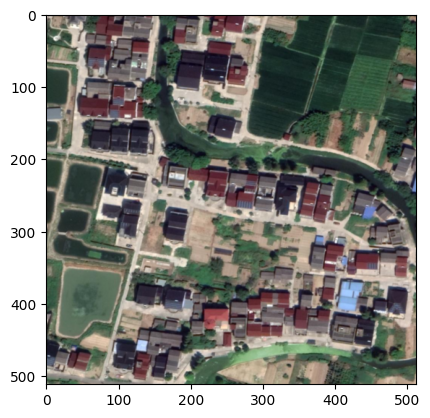

In [ ]:
plt.imshow(sat_img)
plt.imshow(uav_img)

plt.show()